In [2]:
import matplotlib.pyplot as plt
import MLMC
import numpy as np

Nmin=30
M0=32
s=2

c:\Users\wiebe\Documents\Universiteit\Jaar 4\Monte carlo\Project-MC-Methods--MLMC\MLMC.py:30: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  normalisation = [integrate.quad(lambda t: (np.sin(omega(n)*t) + lamb*omega(n)*np.cos(omega(n)*t))**2, 0, 1, limit=50)[0] for n in range(precompute_threshold + 1)]


Lets now check the order of convergence of the Finite Volume Method. We do this by comparing the exact solution with a known manufactured solution

[0, 0.000945560515873013]
[1, 0.00024029589074806918]
[2, 6.055644914213809e-05]
[3, 1.5199067774629045e-05]
[4, 3.8072394019752338e-06]
[5, 9.527425388433383e-07]
[6, 2.383021349545098e-07]
[7, 5.959009112120942e-08]
[8, 1.4899342256523728e-08]
[9, 3.7250627026521933e-09]
[10, 9.312941764810296e-10]
[11, 2.3282708253893006e-10]


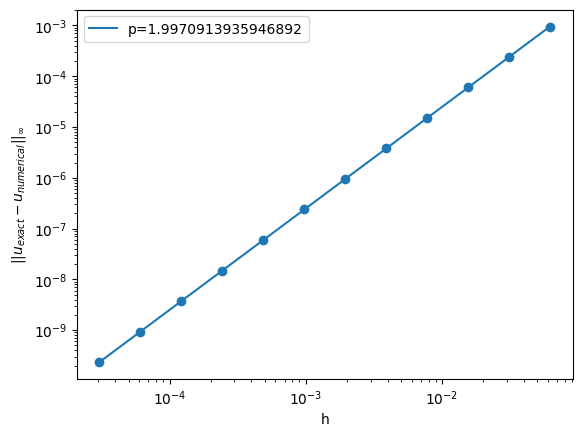

[[9.45560516e-04 2.40295891e-04 6.05564491e-05 1.51990678e-05
  3.80723940e-06 9.52742539e-07 2.38302135e-07 5.95900911e-08
  1.48993423e-08 3.72506270e-09 9.31294176e-10 2.32827083e-10]]
(array([-1.41076607,  1.99709139]), array([[3.24709742e-05, 4.35596367e-06],
       [4.35596367e-06, 6.61508134e-07]]))


In [5]:
import error_analysis
m_vals=16*np.exp2(np.arange(12)).astype(int)
error_analysis.compare_to_exact_solution(MLMC.approximate_solution, MLMC.exact_solution, m_vals)


In [10]:
(result, Y_L, N_vals)=MLMC.MLMC(Nmin, M0, s)

KeyboardInterrupt: 

Below is the code for generating the plots.
First the plot for the variance

(5,)


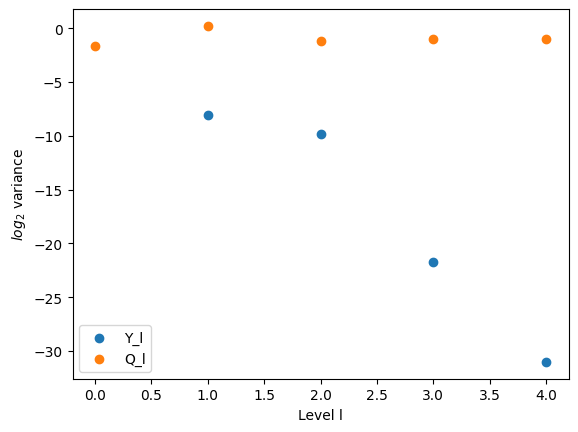

In [3]:
N_vals=16*np.exp2(np.arange(5)).astype(int)#TODO: Remove
sample_num=200
#Compute Q_L variance
Q_L=np.empty((N_vals.size, sample_num))
Q_vars=np.empty(N_vals.shape)

print(N_vals.shape)
for l in range(N_vals.size):
    M=M0*(s**l)
    Q_L[l]=MLMC.draw_Q_L_samples(M, sample_num)
    Q_vars[l]=Q_L[l].var()
#Compute variances of Y_L
Y_L=[np.empty(sample_num)]*len(N_vals)#TODO: Remove
Y_vars=np.empty(len(Y_L))
for l in range(len(Y_L)):
    Y_L[l]=MLMC.draw_Y_L_samples(16, 2, sample_num, l)
    Y_vars[l]=np.var(Y_L[l])
#Compute grid sizes
L_vals=np.arange(N_vals.size)
plt.scatter(L_vals[1:], np.log2(Y_vars[1:]), label="Y_l")
plt.scatter(L_vals, np.log2(Q_vars), label="Q_l")
plt.legend()
plt.xlabel("Level l")
plt.ylabel(r"$log _2$ variance")
plt.show()


Now the plot for the means

Text(0, 0.5, '$log_2$ |mean|')

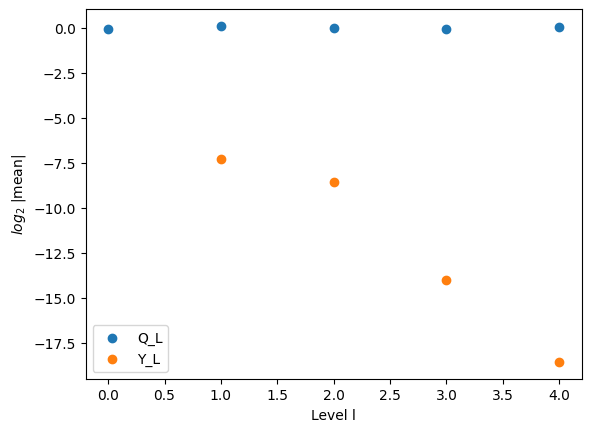

In [4]:
Q_means=np.empty(Q_vars.shape)
for l in range(Q_L.shape[0]):
    Q_means[l]=Q_L[l].mean()
Y_means=np.empty(len(Y_L)-1)
for l in range(1, len(Y_L)):
    Y_means[l-1]=np.mean(Y_L[l])
plt.scatter(L_vals, np.log2(np.abs(Q_means)), label="Q_L")
plt.scatter(L_vals[1:], np.log2(np.abs(Y_means)), label="Y_L")
plt.legend()
plt.xlabel("Level l")
plt.ylabel(r"$log_2$ |mean|")

-3.2698851889276295e-05
-2.7770678823417897e-05
-3.3014311096149525e-05


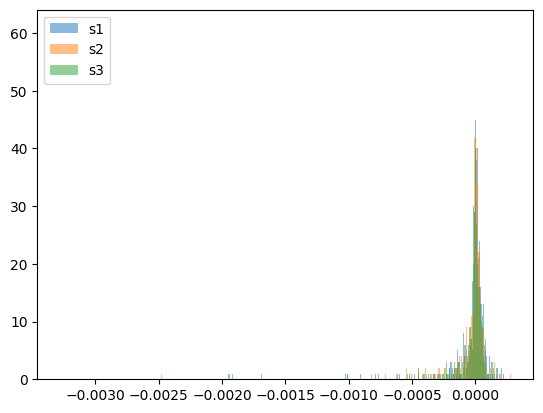

In [16]:
s1=MLMC.draw_Y_L_samples(16, 2, 1000, 2)
s2=MLMC.draw_Y_L_samples(16, 2, 1000, 2)
s3=MLMC.draw_Y_L_samples(16, 2, 1000, 2)
print(np.mean(s1))
print(np.mean(s2))
print(np.mean(s3))

plt.hist(s1, 1000, alpha=0.5, label="s1")
plt.hist(s2, 1000, alpha=0.5, label="s2")
plt.hist(s3, 1000, alpha=0.5, label="s3")
plt.legend()
plt.show()

